# Regression Dataset Preview

This notebook demonstrates the `RegressionDataGenerator` which creates datasets for element concentration regression (Quantitative XRF).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

# Ensure project root is in sys.path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data.regression.generator import RegressionDataGenerator
from src.data.common.base_generator import GeneratorConfig, preview_dataset

## Generate Samples
Generating 50 synthetic spectra with random relative concentrations (summing to 1.0) using a Dirichlet distribution.

In [2]:
gen = RegressionDataGenerator(seed=123)
config = GeneratorConfig.Presets.balanced()
config.summary()

X, y = gen.generate_dataset(num_samples=50, min_elements=2, max_elements=4, config=config)

print(f"X shape: {X.shape} (samples, energy_bins)")
print(f"y shape: {y.shape} (samples, elements)")

----------------------------------------
      XRF Generator Configuration       
----------------------------------------
s_counts_range      : (30000, 80000)
n_counts_range      : (1000, 5000)
b_counts_range      : (3000, 3000)
c_counts_range      : (3000, 3000)
escape_prob         : 1.0
sum_peaks_prob      : 1.0
decal_prob          : 0.0
kvp_range           : (30.0, 30.0)
angle_range         : (46.0, 46.0)
mas_range           : (9.0, 9.0)
target_materials    : ['Mo']
filters             : [('Be', 0.127), ('Air', 10.0)]
----------------------------------------


Generating Regression Dataset: 100%|██████████| 50/50 [00:29<00:00,  1.68it/s]

X shape: (50, 600) (samples, energy_bins)
y shape: (50, 41) (samples, elements)


## Concentration Analysis
Checking the distribution of non-zero concentrations.

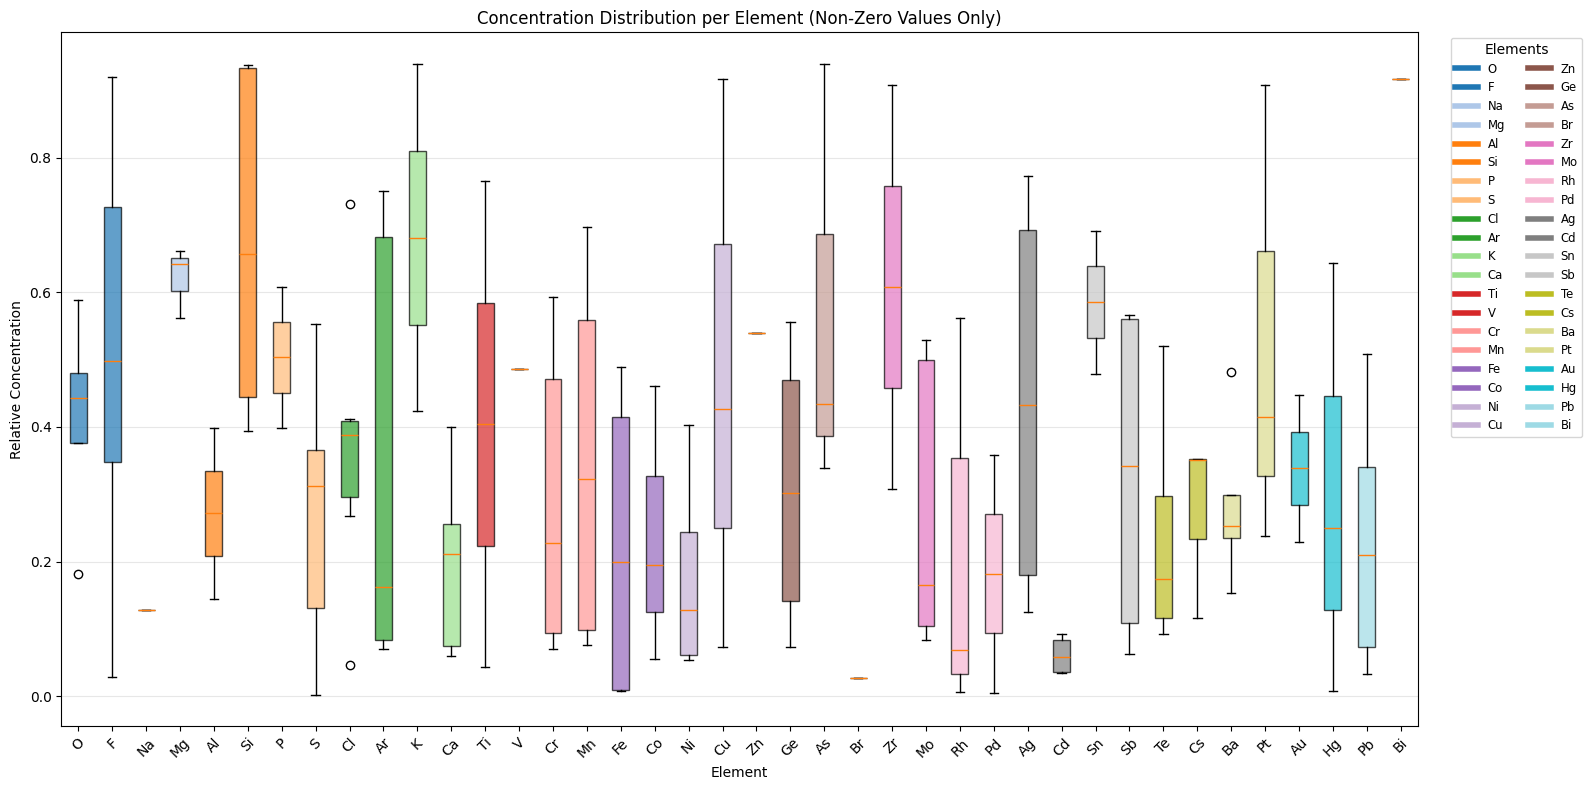

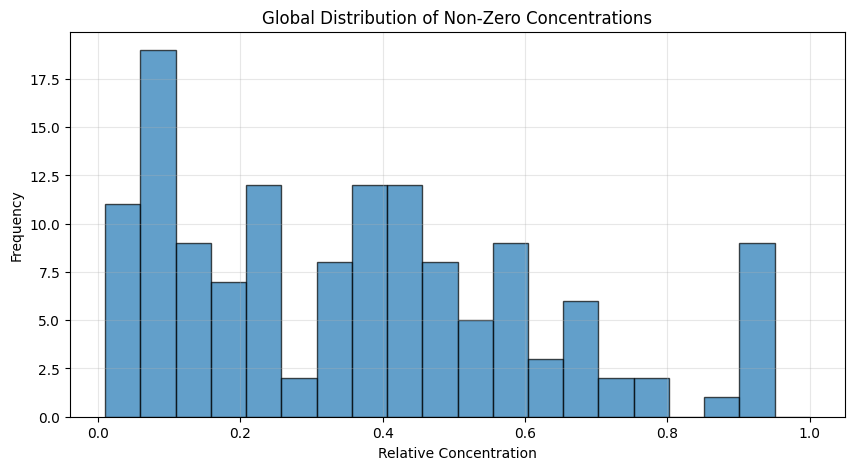

In [3]:
# Filter elements that actually appear in our dataset samples
active_elements = y.columns[(y > 0).any()]
data_to_plot = [y[el][y[el] > 0] for el in active_elements]

plt.figure(figsize=(16, 8))
bp = plt.boxplot(data_to_plot, tick_labels=active_elements, patch_artist=True)

# Apply colors to boxes
colors = plt.cm.tab20(np.linspace(0, 1, len(active_elements)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title("Concentration Distribution per Element (Non-Zero Values Only)")
plt.xlabel("Element")
plt.ylabel("Relative Concentration")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors[i], lw=4, label=el) for i, el in enumerate(active_elements)]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', title="Elements", ncol=2, fontsize='small')

plt.tight_layout()
plt.show()

# Global histogram for overall concentration statistics
plt.figure(figsize=(10, 5))
plt.hist(y[y > 0].values.flatten(), bins=20, range=(0.01, 1), edgecolor='black', alpha=0.7)
plt.title("Global Distribution of Non-Zero Concentrations")
plt.xlabel("Relative Concentration")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

## Correlation Analysis
Visualizing the correlation between element concentrations. Since they must sum to 1.0, we expect some slight negative correlations.

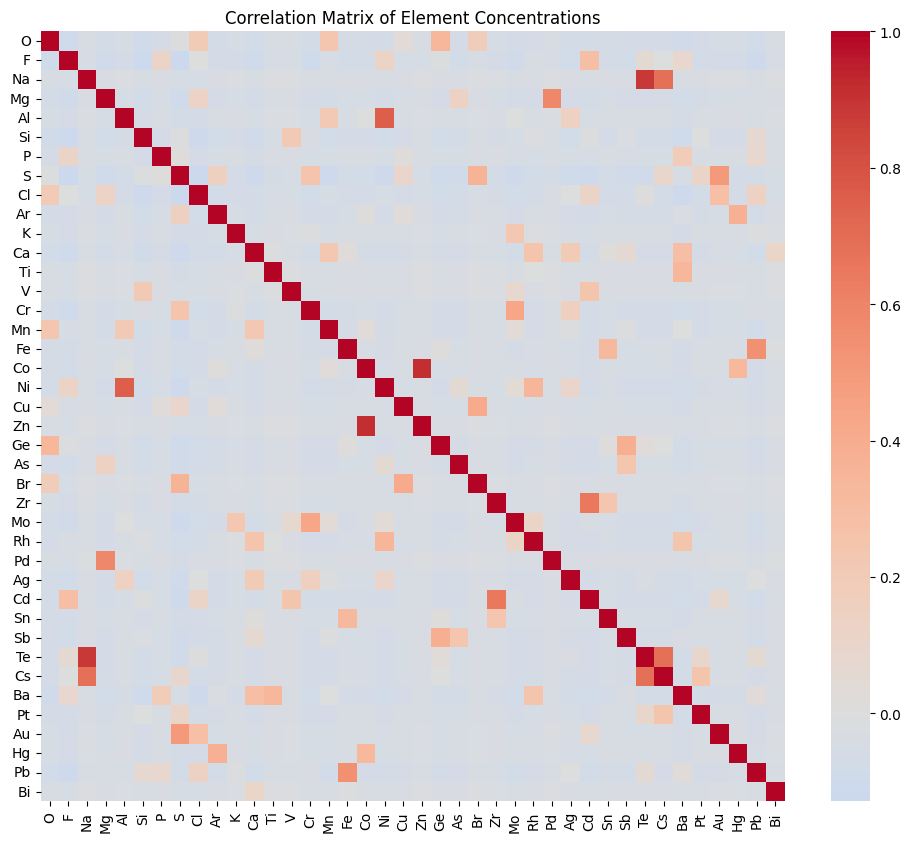

In [4]:
import seaborn as sns

# Filter elements that have some presence in the dataset
active_y = y.loc[:, (y > 0).any()]
corr_matrix = active_y.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix of Element Concentrations")
plt.show()

## Preview Spectra & Regression Targets
Overlaying the ground truth concentrations for a few samples.

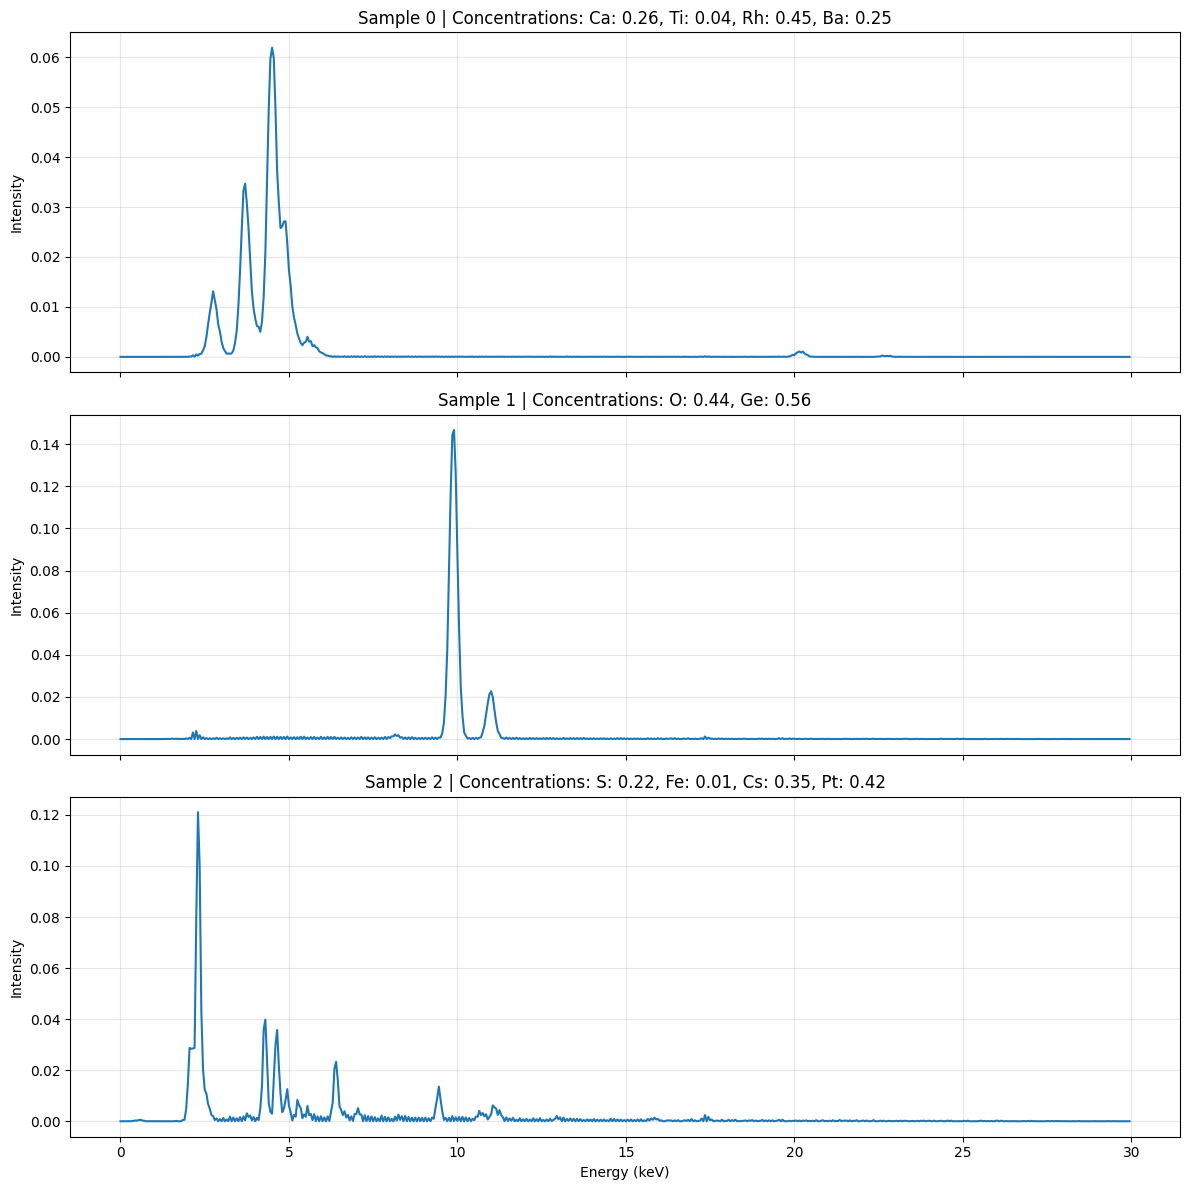

In [5]:
num_previews = 3
energies = np.arange(0, 30, 0.05)

fig, axes = plt.subplots(num_previews, 1, figsize=(12, 4 * num_previews), sharex=True)

for i in range(num_previews):
    ax = axes[i]
    ax.plot(energies, X[i])
    
    # Get active concentrations
    sample_concs = y.iloc[i][y.iloc[i] > 0]
    label_str = ", ".join([f"{el}: {c:.2f}" for el, c in sample_concs.items()])
    
    ax.set_title(f"Sample {i} | Concentrations: {label_str}")
    ax.set_ylabel("Intensity")
    ax.grid(alpha=0.3)

plt.xlabel("Energy (keV)")
plt.tight_layout()
plt.show()